In [20]:
#Librerias a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


# EDA inicial

In [6]:

#Definicion de columnas y lectura de datos
cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","num"]

df = pd.read_csv("processed.cleveland.data", names=cols, na_values="?")
df = df.dropna()

# target binario: 0 = sin enfermedad, 1 = con enfermedad
df["target"] = (df["num"] > 0).astype(int)

df.shape, df["target"].value_counts()

((297, 15),
 target
 0    160
 1    137
 Name: count, dtype: int64)

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


Notamos que en la columna sex tenemos un promedio de 0.67, indicando que mas del 50% de registros son hombres

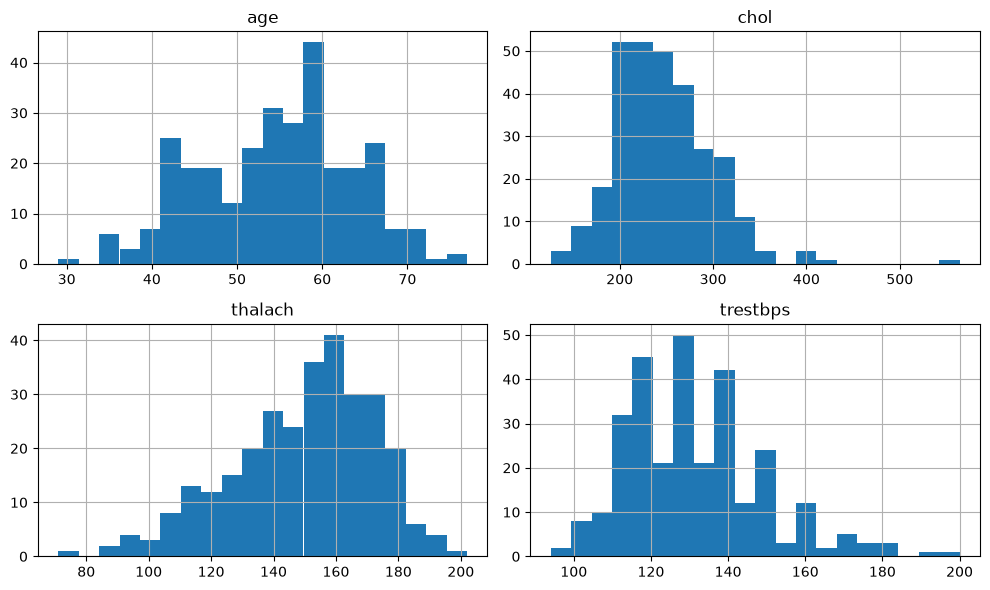

target,0,1
sex,,
0.0,0.739583,0.260417
1.0,0.442786,0.557214


In [9]:
# Distribución del target
df["target"].value_counts(normalize=True)

# Histogramas de las variables clave
df[["age","chol","thalach","trestbps"]].hist(figsize=(10,6), bins=20)
plt.tight_layout()
plt.show()

# Tabla de contingencia: sexo vs enfermedad
pd.crosstab(df["sex"], df["target"], normalize="index")

Notamos de las distribuciones que *thalach* (Frecuencia cardiaca máxima alcanzada durante la prueba de esfuerzo) tiene un comportamiento asimetrico, con una cola a la izquierda. Tambien que, en este dataset la enfermedad es detectada en una propocion mas grande de hombres que en mujeres.

# Probabilidad Condicional

In [10]:
asintomatico = df[df["cp"] == 4]
p_enf_dado_asintomatico = asintomatico["target"].mean()
p_enf_marginal = df["target"].mean()

print(f"P(enfermedad) marginal = {p_enf_marginal:.3f}")
print(f"P(enfermedad | dolor asintomático) = {p_enf_dado_asintomatico:.3f}")

P(enfermedad) marginal = 0.461
P(enfermedad | dolor asintomático) = 0.725


El dolor de pecho clasificado como "asintomático" (cp=4) casi duplica en términos relativos la probabilidad de enfermedad cardíaca respecto a la probabilidad poblacional (72.5% vs 46.1%).
El ser "asintomático" no debe interpretarse como bajo riesgo.
Para la red de clínicas, esto podria llegar a sugerir que el protocolo de triage no debería tranquilizarse ante la ausencia de dolor típico

#Teorema de Bayes

In [11]:
# Prior
p_enfermedad = df["target"].mean()          # P(E)
p_no_enfermedad = 1 - p_enfermedad          # P(¬E)

# Verosimilitudes: P(angina | E) y P(angina | ¬E)
p_angina_dado_enf = df[df["target"]==1]["exang"].mean()
p_angina_dado_no_enf = df[df["target"]==0]["exang"].mean()

# Evidencia total (denominador de Bayes)
p_angina = p_angina_dado_enf*p_enfermedad + p_angina_dado_no_enf*p_no_enfermedad

# Bayes
p_enf_dado_angina = (p_angina_dado_enf * p_enfermedad) / p_angina

print(f"Prior P(enfermedad) = {p_enfermedad:.3f}")
print(f"P(angina | enfermedad) = {p_angina_dado_enf:.3f}")
print(f"P(angina | sin enfermedad) = {p_angina_dado_no_enf:.3f}")
print(f"Posterior P(enfermedad | angina) = {p_enf_dado_angina:.3f}")

Prior P(enfermedad) = 0.461
P(angina | enfermedad) = 0.540
P(angina | sin enfermedad) = 0.144
Posterior P(enfermedad | angina) = 0.763


Partiendo de un prior poblacional de 46.1%, el resultado positivo en la prueba de angina inducida por ejercicio eleva la probabilidad de enfermedad a 76.3%. 
Lo que aporta el Teorema de Bayes aquí es invertir la pregunta: los médicos miden fácilmente P(angina | enfermedad) observando pacientes ya diagnosticados, pero lo clínicamente útil es la pregunta inversa, P(enfermedad | angina), que solo se obtiene aplicando Bayes. La gran
diferencia entre P(angina|enfermedad)=0.540 y P(angina|sin enfermedad)=0.144 explica por qué esta evidencia mueve tanto la probabilidad: si ambas verosimilitudes fueran parecidas, la angina no aportaría información diagnóstica.

#Verosimilitud y MLE

Enfermos:  mu=251.9, sigma=49.5
Sanos:     mu=243.5, sigma=53.6


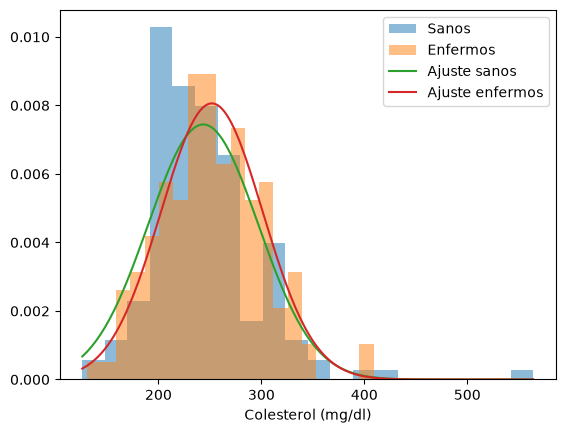

In [12]:
chol_enf = df[df["target"]==1]["chol"]
chol_sano = df[df["target"]==0]["chol"]

# MLE de una Normal = media y varianza muestral
mu_enf, sigma_enf = chol_enf.mean(), chol_enf.std(ddof=0)
mu_sano, sigma_sano = chol_sano.mean(), chol_sano.std(ddof=0)

print(f"Enfermos:  mu={mu_enf:.1f}, sigma={sigma_enf:.1f}")
print(f"Sanos:     mu={mu_sano:.1f}, sigma={sigma_sano:.1f}")

x = np.linspace(df["chol"].min(), df["chol"].max(), 200)
plt.hist(chol_sano, bins=20, density=True, alpha=0.5, label="Sanos")
plt.hist(chol_enf, bins=20, density=True, alpha=0.5, label="Enfermos")
plt.plot(x, stats.norm.pdf(x, mu_sano, sigma_sano), label="Ajuste sanos")
plt.plot(x, stats.norm.pdf(x, mu_enf, sigma_enf), label="Ajuste enfermos")
plt.legend(); plt.xlabel("Colesterol (mg/dl)"); plt.show()

Los parámetros estimados por máxima verosimilitud muestran medias muy cercanas entre ambos grupos (diferencia de 8.4 mg/dl) y desviaciones estándar similares. 
Visualmente, ambas curvas se superponen casi por completo. Esto sugiere que el colesterol total por sí solo tiene poco poder discriminante entre pacientes con y sin enfermedad cardíaca en esta muestra. Para la clínica, esto implica que
el colesterol no debería usarse como criterio único de riesgo.

# Distribuciones paramétricas

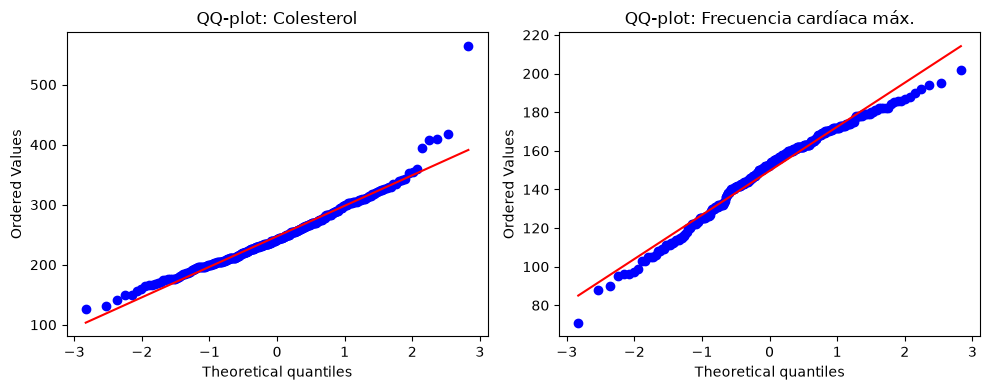

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df["chol"], dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot: Colesterol")
stats.probplot(df["thalach"], dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot: Frecuencia cardíaca máx.")
plt.tight_layout()
plt.show()

#### Variables discretas
sex:  Bernoulli por ser binaria (p=0.677)
cp:   Categórica (4 niveles) — proporciones 47.8% / 27.9% / 16.5% / 7.7%
### Variables continuas
chol: aproximadamente Gaussiana en el centro, con cola pesada a la derecha (el QQ-plot se desvía de la recta en los valores altos, por outliers)
thalach: buena aproximación Gaussiana (el QQ-plot sigue la recta de forma más consistente que colesterol, con leve desviación en el extremo inferior)
La frecuencia cardiaca maxima se modela bien como Gaussiana, mientras que el colesterol requeriría un modelo con colas más pesadas (ej. log-normal) para capturar los valores extremos observados.

# Esperanza y varianza

In [15]:
grp = df.groupby("target")["thalach"].agg(["mean", "var"])
print(grp)

              mean         var
target                        
0       158.581250  362.647445
1       139.109489  515.774689


Sin enfermedad (target=0): E[thalach] = 158.6 lpm, Var[thalach] = 362.6
Con enfermedad (target=1): E[thalach] = 139.1 lpm, Var[thalach] = 515.8

Los pacientes sin enfermedad alcanzan, en promedio, una frecuencia cardíaca máxima 19.5 lpm más alta que los pacientes con enfermedad consistente
con la fisiología esperada, ya que una menor capacidad de esfuerzo cardíaco es un indicador clínico de enfermedad coronaria. Además, la varianza es un 42% mayoren el grupo enfermo, lo que sugiere que la enfermedad cardíaca se presenta con un espectro más heterogéneo de capacidad funcional, mientras que los pacientes sanos son más consistentes entre sí. Para la clínica, esto refuerza que thalach es un buen indicador de riesgo, pero su variabilidad en el grupo enfermo sugiere que no debe usarse de forma aislada para descartar enfermedad.

# Independencia y correlacion

target   0    1
sex            
0.0     71   25
1.0     89  112
chi2=21.85, p-valor=0.0000


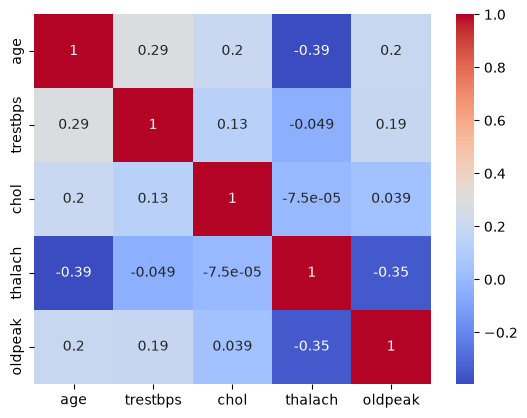

In [16]:
# Tabla de contingencia sexo vs enfermedad
tabla = pd.crosstab(df["sex"], df["target"])
chi2, p, dof, expected = stats.chi2_contingency(tabla)
print(tabla)
print(f"chi2={chi2:.2f}, p-valor={p:.4f}")

# Matriz de correlación de variables numéricas
num_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]
corr = df[num_vars].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Independencia
el p-valor de 0 lleva a rechazar la hipótesis de independencia entre sexo y enfermedad cardíaca. En
términos de negocio, esto significa que el sexo es un factor de riesgo real que
la clínica debería incorporar en sus protocolos de evaluación —si estas dos
variables FUERAN independientes, saber el sexo del paciente no aportaría ninguna
información sobre su riesgo de enfermedad, y aquí claramente sí aporta.

### Correlación
ninguna correlación entre variables numéricas supera
|0.4|, por lo que no hay evidencia de multicolinealidad grave. Las correlaciones
más fuertes son age–thalach (-0.39) y thalach–oldpeak (-0.35), ambas
fisiológicamente consistentes: a mayor edad, menor frecuencia cardíaca máxima
alcanzable; y una menor frecuencia máxima se asocia a mayor depresión del
segmento ST durante el esfuerzo.

# Prior y Posterior

In [17]:
prior = df["target"].mean()

def actualizar(prior, variable, valor_observado):
    p_dado_enf = df[df["target"]==1][variable].eq(valor_observado).mean()
    p_dado_sano = df[df["target"]==0][variable].eq(valor_observado).mean()
    evidencia = p_dado_enf*prior + p_dado_sano*(1-prior)
    posterior = (p_dado_enf * prior) / evidencia
    return posterior

# Orden 1: primero cp, luego exang
p1 = actualizar(prior, "cp", 4)
p2 = actualizar(p1, "exang", 1)

print(f"Prior:            {prior:.3f}")
print(f"Tras cp=4:        {p1:.3f}")
print(f"Tras exang=1:     {p2:.3f}")

# Orden 2 (invertido): primero exang, luego cp
q1 = actualizar(prior, "exang", 1)
q2 = actualizar(q1, "cp", 4)
print(f"Orden invertido -> tras exang=1: {q1:.3f}, tras cp=4: {q2:.3f}")

Prior:            0.461
Tras cp=4:        0.725
Tras exang=1:     0.908
Orden invertido -> tras exang=1: 0.763, tras cp=4: 0.908


Prior: 0.461
Orden A 
tras cp=4:0.725
tras exang=1: 0.908
Orden B
tras exang=1: 0.763
tras cp=4: 0.908

El posterior final es idéntico en ambos órdenes, a pesar de que los valores intermedios difieren (0.725 vs 0.763). 
Esto ocurre
porque el método de actualización secuencial usado asume independencia
condicional entre cp y exang dado el diagnóstico (enfoque tipo Naive Bayes):
cada evidencia se pondera contra el prior original de forma independiente, por
lo que el orden de llegada de la información no afecta la conclusión final,
aunque sí afecta la "narrativa" del razonamiento diagnóstico en el camino.
Para la clínica, esto es tranquilizador: no importa en qué orden lleguen los
resultados de las pruebas (dolor de pecho vs. angina inducida), el diagnóstico
probabilístico final converge al mismo valor.

# Entropia

In [19]:
def entropia_binaria(p):
    if p in (0, 1):
        return 0
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))

H_total = entropia_binaria(df["target"].mean())
print(f"Entropía total de target: {H_total:.3f} bits")

H_cond = 0
for val, sub in df.groupby("cp"):
    peso = len(sub) / len(df)
    p_local = sub["target"].mean()
    H_cond += peso * entropia_binaria(p_local)

print(f"Entropía condicional dado cp: {H_cond:.3f} bits")
print(f"Ganancia de información: {H_total - H_cond:.3f} bits")

Entropía total de target: 0.996 bits
Entropía condicional dado cp: 0.798 bits
Ganancia de información: 0.197 bits


La entropía total de 0.996 bits (Cercana al máximo teórico de 1 bit) refleja que, sin información adicional, el diagnóstico es altamente incierto en esta población Al condicionar en el tipo de dolor de pecho, la incertidumbre se reduce a 0.798
bits, una ganancia de información de 0.197 bits. Esto confirma cuantitativamente
que cp es una variable diagnóstica útil: por sí sola reduce cerca de un 20% la
incertidumbre sobre el diagnóstico, lo que la convierte en un buen primer filtro
de triage clínico, aunque claramente insuficiente para diagnosticar por sí sola
(persiste el 80% restante de incertidumbre).

# Entropia cruzada

In [ ]:
#Definición de variables predictoras y target
X = df[["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal"]]
y = df["target"]

#Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

train_probs = modelo.predict_proba(X_train)[:,1]
test_probs = modelo.predict_proba(X_test)[:,1]

print(f"Entropía cruzada (train): {log_loss(y_train, train_probs):.3f}")
print(f"Entropía cruzada (test):  {log_loss(y_test, test_probs):.3f}")

Entropía cruzada (train): 0.367
Entropía cruzada (test):  0.297


Ambas entropías cruzadas son relativamente bajas y del mismo orden de magnitud, sin evidencia de sobreajuste (la de test no es mayor que la de train). 
De hecho, el valor de test es ligeramente menor, lo cual con un dataset de solo 297 pacientes (74 en el conjunto de prueba) es plausible por variabilidad del muestreo aleatorio, más que por una generalización excepcional del modelo.
Para la clínica, esto sugiere que el modelo logístico captura señal real en las
variables clínicas, pero la conclusión debe tomarse con cautela dado el tamaño
muestral reducido; se recomendaría validar con una muestra externa antes de
usarlo como herramienta de apoyo diagnóstico real.

# Divergencia KL

In [ ]:
bins = np.linspace(df["chol"].min(), df["chol"].max(), 15)

p_enf, _ = np.histogram(df[df["target"]==1]["chol"], bins=bins, density=True)
p_sano, _ = np.histogram(df[df["target"]==0]["chol"], bins=bins, density=True)

eps = 1e-8
p_enf = p_enf/p_enf.sum() + eps
p_sano = p_sano/p_sano.sum() + eps

kl = entropy(p_enf, p_sano)
print(f"Divergencia KL(colesterol enfermos || sanos) = {kl:.4f}")

# Comparación
bins2 = np.linspace(df["thalach"].min(), df["thalach"].max(), 15)
p_enf2, _ = np.histogram(df[df["target"]==1]["thalach"], bins=bins2, density=True)
p_sano2, _ = np.histogram(df[df["target"]==0]["thalach"], bins=bins2, density=True)
p_enf2 = p_enf2/p_enf2.sum() + eps
p_sano2 = p_sano2/p_sano2.sum() + eps
kl2 = entropy(p_enf2, p_sano2)
print(f"Divergencia KL(thalach enfermos || sanos) = {kl2:.4f}")

Divergencia KL(colesterol enfermos || sanos) = 0.0877
Divergencia KL(thalach enfermos || sanos) = 0.6362


La divergencia KL del colesterol es baja (0.0877), confirmando cuantitativamente lo observado en el análisis de MLE: las distribuciones de colesterol entre pacientes con y sin enfermedad son muy similares
Por lo que
esta variable aporta poca capacidad discriminante por sí sola. En contraste, la
divergencia KL de thalach es más de 7 veces mayor (0.6362), evidenciando que la
frecuencia cardíaca máxima separa mucho mejor a ambas poblaciones. Para la red
de clínicas, esto tiene una implicación directa: los protocolos de triage que
dan peso importante al colesterol como indicador aislado de riesgo cardíaco
deberían reconsiderar su ponderación, priorizando en su lugar variables como la
frecuencia cardíaca máxima alcanzada en pruebas de esfuerzo.